In [1]:
# =============================================================================
# DETECTION DU GLAUCOME PAR DEEP LEARNING
# Modèle: EfficientNet-B0 avec Transfer Learning
# =============================================================================

# =============================================================================
# 1. IMPORTATION DES BIBLIOTHEQUES
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import json

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Metriques
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                            roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay)

# Autres
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Bibliotheques importees avec succes")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")


Bibliotheques importees avec succes
PyTorch version: 2.6.0+cu124
CUDA disponible: True


In [2]:
# =============================================================================
# 2. CONFIGURATION GLOBALE
# =============================================================================

# Hyperparametres
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice utilise: {DEVICE}")

# Seed pour reproductibilite
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f"Configuration:")
print(f"  - Taille images: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Epochs max: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print(f"  - Seed: {SEED}")



Device utilise: cuda
Configuration:
  - Taille images: 224x224
  - Batch size: 16
  - Epochs max: 50
  - Learning rate: 0.0001
  - Seed: 42


In [3]:
# =============================================================================
# 3. CHARGEMENT DES DONNEES
# =============================================================================

# Chemin du dataset
DATA_PATH = "/kaggle/input/drishtigs-retina-dataset-for-onh-segmentation"

print(f"\nChargement du dataset depuis: {DATA_PATH}")
print("Analyse de la structure des dossiers...")

# Parcourir les dossiers et creer le dataframe
image_paths = []
labels = []

for root, dirs, files in os.walk(DATA_PATH):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            full_path = os.path.join(root, file)
            image_paths.append(full_path)
            
            # Determiner le label selon le chemin
            if 'glaucoma' in root.lower() or 'glau' in file.lower():
                labels.append(1)  # Glaucome
            else:
                labels.append(0)  # Normal

# Creer le DataFrame
df = pd.DataFrame({
    'image_path': image_paths,
    'label': labels
})

print(f"\nDataset charge:")
print(f"  Total d'images: {len(df)}")
print(f"\nDistribution des classes:")
print(df['label'].value_counts())
print(f"\nPourcentages:")
print(df['label'].value_counts(normalize=True) * 100)

# Verifier qu'il y a bien des donnees
if len(df) == 0:
    raise ValueError("Aucune image trouvee. Verifiez le chemin DATA_PATH.")



Chargement du dataset depuis: /kaggle/input/drishtigs-retina-dataset-for-onh-segmentation
Analyse de la structure des dossiers...

Dataset charge:
  Total d'images: 303

Distribution des classes:
label
0    233
1     70
Name: count, dtype: int64

Pourcentages:
label
0    76.89769
1    23.10231
Name: proportion, dtype: float64


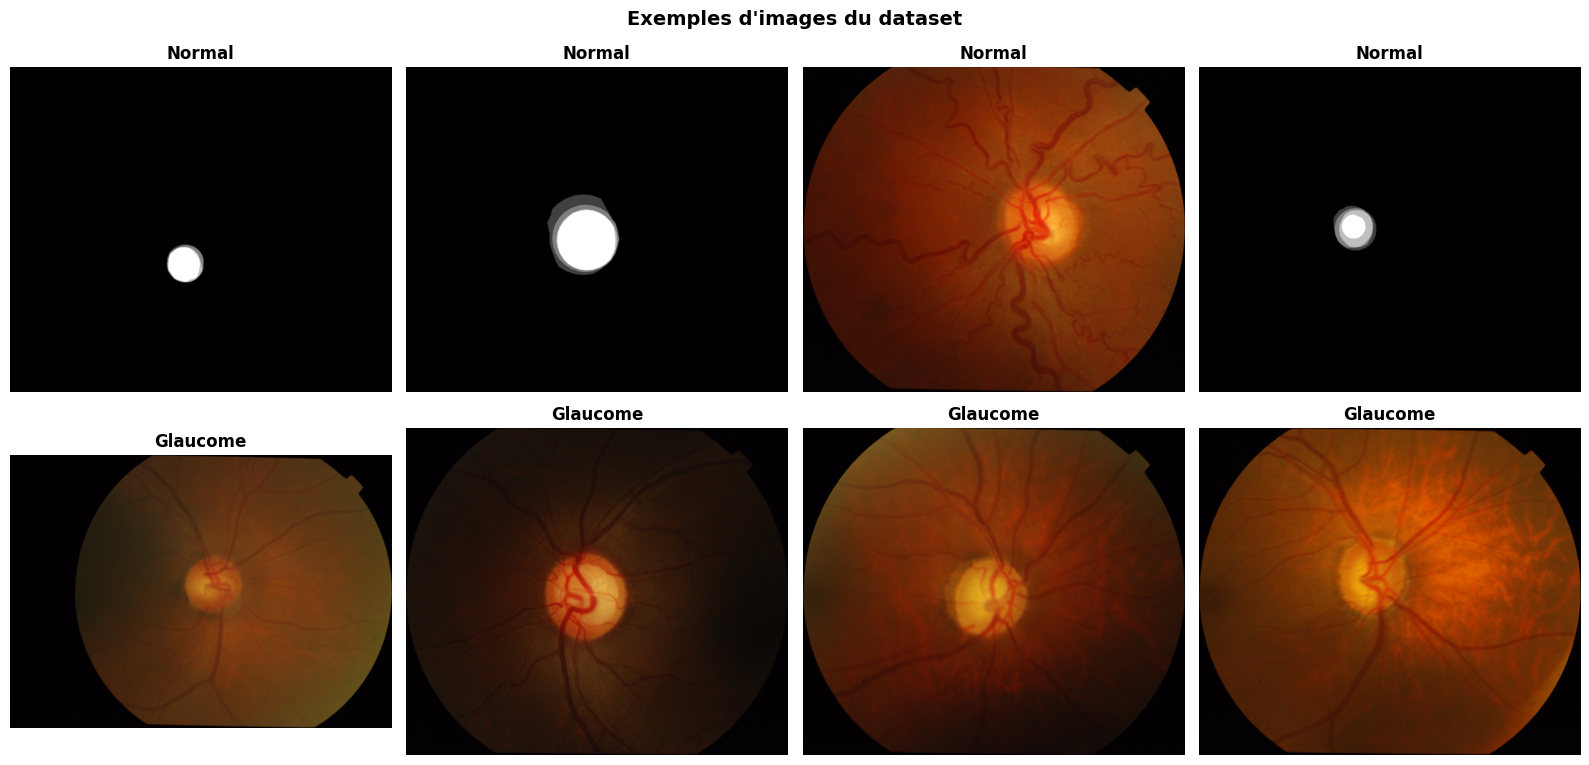


Visualisations sauvegardees dans 'dataset_samples.png'


In [4]:
# =============================================================================
# 4. ANALYSE EXPLORATOIRE DES DONNEES
# =============================================================================

# Visualiser quelques exemples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

# Selectionner 4 images normales et 4 glaucomes
normal_samples = df[df['label'] == 0].sample(n=4, random_state=SEED)
glaucoma_samples = df[df['label'] == 1].sample(n=4, random_state=SEED)
samples = pd.concat([normal_samples, glaucoma_samples])

for idx, (ax, (_, row)) in enumerate(zip(axes, samples.iterrows())):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
    label_text = 'Normal' if row['label'] == 0 else 'Glaucome'
    ax.set_title(f'{label_text}', fontsize=12, fontweight='bold')

plt.suptitle('Exemples d\'images du dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualisations sauvegardees dans 'dataset_samples.png'")


In [5]:
# =============================================================================
# 5. DIVISION DU DATASET
# =============================================================================

# Split stratifie: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(
    df, 
    test_size=0.3, 
    stratify=df['label'], 
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.5, 
    stratify=temp_df['label'], 
    random_state=SEED
)

print(f"\nRepartition des donnees:")
print(f"  Train:      {len(train_df):3d} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Validation: {len(val_df):3d} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:       {len(test_df):3d} images ({len(test_df)/len(df)*100:.1f}%)")

print(f"\nDistribution par classe:")
for split_name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    normal = len(split_df[split_df['label'] == 0])
    glaucoma = len(split_df[split_df['label'] == 1])
    print(f"  {split_name:5s} - Normal: {normal:3d}, Glaucome: {glaucoma:3d}")



Repartition des donnees:
  Train:      212 images (70.0%)
  Validation:  45 images (14.9%)
  Test:        46 images (15.2%)

Distribution par classe:
  Train - Normal: 163, Glaucome:  49
  Val   - Normal:  35, Glaucome:  10
  Test  - Normal:  35, Glaucome:  11


In [6]:
# =============================================================================
# 6. CREATION DU DATASET PYTORCH
# =============================================================================

class GlaucomaDataset(Dataset):
    """
    Dataset personnalise pour la detection du glaucome.
    """
    
    def __init__(self, dataframe, transform=None):
        """
        Args:
            dataframe: DataFrame contenant 'image_path' et 'label'
            transform: Transformations torchvision
        """
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Charger l'image
        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']
        
        # Ouvrir et convertir en RGB
        image = Image.open(img_path).convert('RGB')
        
        # Appliquer les transformations
        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.float32)

print("\nClasse GlaucomaDataset definie")



Classe GlaucomaDataset definie


In [7]:
# =============================================================================
# 7. TRANSFORMATIONS ET DATA AUGMENTATION
# =============================================================================

# Transformations pour l'entrainement (avec augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Moyennes ImageNet
        std=[0.229, 0.224, 0.225]     # Ecarts-types ImageNet
    )
])

# Transformations pour validation/test (sans augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nTransformations definies:")
print("  Train: Resize, Flip, Rotation, ColorJitter, Normalize")
print("  Val/Test: Resize, Normalize")



Transformations definies:
  Train: Resize, Flip, Rotation, ColorJitter, Normalize
  Val/Test: Resize, Normalize


In [8]:
# =============================================================================
# 8. CREATION DES DATALOADERS
# =============================================================================

# Creer les datasets
train_dataset = GlaucomaDataset(train_df, transform=train_transform)
val_dataset = GlaucomaDataset(val_df, transform=val_transform)
test_dataset = GlaucomaDataset(test_df, transform=val_transform)

# Creer les dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nDataLoaders crees:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")



DataLoaders crees:
  Train: 14 batches
  Val:   3 batches
  Test:  3 batches


In [9]:
# =============================================================================
# 9. CONSTRUCTION DU MODELE - EFFICIENTNET-B0
# =============================================================================

# Charger EfficientNet-B0 pre-entraine
model = models.efficientnet_b0(pretrained=True)

# Geler les premieres couches (Transfer Learning)
# On gele les 5 premiers blocs de features
for param in model.features[:5].parameters():
    param.requires_grad = False

# Modifier le classifier pour classification binaire
num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, 1)
)

# Deplacer le modele sur GPU
model = model.to(DEVICE)

# Calculer le nombre de parametres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModele: EfficientNet-B0")
print(f"  Total parametres: {total_params:,}")
print(f"  Parametres entrainables: {trainable_params:,}")
print(f"  Parametres geles: {total_params - trainable_params:,}")
print(f"  Ratio entrainable: {trainable_params/total_params*100:.1f}%")
print(f"  Device: {DEVICE}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]



Modele: EfficientNet-B0
  Total parametres: 4,796,541
  Parametres entrainables: 4,487,881
  Parametres geles: 308,660
  Ratio entrainable: 93.6%
  Device: cuda


In [10]:
# =============================================================================
# 10. CONFIGURATION LOSS, OPTIMIZER ET SCHEDULER
# =============================================================================


# Calculer le desequilibre des classes
num_normal = len(df[df['label'] == 0])
num_glaucoma = len(df[df['label'] == 1])
pos_weight = num_normal / num_glaucoma

print(f"\nDesequilibre des classes:")
print(f"  Normal: {num_normal} images")
print(f"  Glaucome: {num_glaucoma} images")
print(f"  Ratio: {pos_weight:.3f}:1")

# Loss function avec ponderation
weight = torch.tensor([pos_weight]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=weight)

# Optimizer AdamW
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    verbose=True,
    min_lr=1e-7
)

print(f"\nConfiguration:")
print(f"  Loss: BCEWithLogitsLoss (pos_weight={pos_weight:.3f})")
print(f"  Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)")



Desequilibre des classes:
  Normal: 233 images
  Glaucome: 70 images
  Ratio: 3.329:1

Configuration:
  Loss: BCEWithLogitsLoss (pos_weight=3.329)
  Optimizer: AdamW (lr=0.0001, wd=0.0005)
  Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)


In [11]:
# =============================================================================
# 11. EARLY STOPPING
# =============================================================================

class EarlyStopping:
    """
    Classe pour implementer l'early stopping et eviter l'overfitting.
    """
    
    def __init__(self, patience=7, min_delta=0.001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model = None
    
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model = model.state_dict()
            self.counter = 0

early_stopping = EarlyStopping(patience=7, verbose=True)

print("\nEarly Stopping configure (patience=7)")



Early Stopping configure (patience=7)


In [12]:
# =============================================================================
# 12. FONCTION D'ENTRAINEMENT
# =============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Entraine le modele sur une epoch.
    
    Returns:
        tuple: (loss, accuracy, auc)
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc="Training", leave=False)
    
    for images, labels in pbar:
        # Deplacer sur GPU
        images = images.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
        
        # Forward pass
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metriques
        running_loss += loss.item()
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calcul metriques epoch
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc

print("Fonction train_epoch definie")


Fonction train_epoch definie


In [13]:
# =============================================================================
# 13. FONCTION DE VALIDATION
# =============================================================================

def validate_epoch(model, loader, criterion, device):
    """
    Evalue le modele sur le set de validation.
    
    Returns:
        tuple: (loss, accuracy, auc)
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False)
        
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc

print("Fonction validate_epoch definie")


Fonction validate_epoch definie


In [14]:
# =============================================================================
# 14. BOUCLE D'ENTRAINEMENT PRINCIPALE
# =============================================================================


SAVE_PATH = 'best_efficientnet_glaucoma.pth'

# Historique
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_auc': [], 'val_auc': [],
    'lr': []
}

best_val_auc = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Entrainement
    train_loss, train_acc, train_auc = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    
    # Validation
    val_loss, val_acc, val_auc = validate_epoch(
        model, val_loader, criterion, DEVICE
    )
    
    # Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Sauvegarder historique
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    history['lr'].append(current_lr)
    
    # Affichage
    print(f"\nResultats Epoch {epoch+1}:")
    print(f"  Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | AUC: {train_auc:.4f}")
    print(f"  Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | AUC: {val_auc:.4f}")
    print(f"  LR: {current_lr:.2e}")
    
    # Sauvegarder meilleur modele
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': val_auc,
            'val_acc': val_acc,
            'history': history
        }, SAVE_PATH)
        print(f"  Meilleur modele sauvegarde (AUC: {val_auc:.4f})")
    
    # Early stopping
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print(f"\nEarly Stopping declenche a l'epoch {epoch+1}")
        print(f"Meilleur Val AUC: {best_val_auc:.4f}")
        model.load_state_dict(early_stopping.best_model)
        break


print("ENTRAINEMENT TERMINE")

print(f"Meilleur Val AUC: {best_val_auc:.4f}")
print(f"Modele sauvegarde: {SAVE_PATH}")



Epoch 1/50
----------------------------------------------------------------------



Resultats Epoch 1:
  Train - Loss: 0.8027 | Acc: 0.7830 | AUC: 0.8977
  Val   - Loss: 0.8546 | Acc: 0.8889 | AUC: 0.9457
  LR: 1.00e-04
  Meilleur modele sauvegarde (AUC: 0.9457)

Epoch 2/50
----------------------------------------------------------------------



Resultats Epoch 2:
  Train - Loss: 0.5446 | Acc: 0.8726 | AUC: 0.9360
  Val   - Loss: 0.5087 | Acc: 0.8889 | AUC: 0.9629
  LR: 1.00e-04
  Meilleur modele sauvegarde (AUC: 0.9629)

Epoch 3/50
----------------------------------------------------------------------



Resultats Epoch 3:
  Train - Loss: 0.4763 | Acc: 0.8726 | AUC: 0.9529
  Val   - Loss: 0.4408 | Acc: 0.8889 | AUC: 0.9714
  LR: 1.00e-04
  Meilleur modele sauvegarde (AUC: 0.9714)

Epoch 4/50
----------------------------------------------------------------------



Resultats Epoch 4:
  Train - Loss: 0.5266 | Acc: 0.8726 | AUC: 0.9444
  Val   - Loss: 0.3664 | Acc: 0.8889 | AUC: 0.9686
  LR: 1.00e-04

Epoch 5/50
----------------------------------------------------------------------


...


Resultats Epoch 15:
  Train - Loss: 0.1652 | Acc: 0.9575 | AUC: 0.9972
  Val   - Loss: 0.4656 | Acc: 0.9111 | AUC: 0.9714
  LR: 1.00e-04
  EarlyStopping counter: 3/7

Epoch 16/50
----------------------------------------------------------------------



Resultats Epoch 16:
  Train - Loss: 0.0845 | Acc: 0.9906 | AUC: 0.9997
  Val   - Loss: 0.3433 | Acc: 0.9111 | AUC: 0.9629
  LR: 1.00e-04
  EarlyStopping counter: 4/7

Epoch 17/50
----------------------------------------------------------------------



Resultats Epoch 17:
  Train - Loss: 0.2258 | Acc: 0.9764 | AUC: 0.9667
  Val   - Loss: 0.3454 | Acc: 0.9111 | AUC: 0.9686
  LR: 1.00e-04
  EarlyStopping counter: 5/7

Epoch 18/50
----------------------------------------------------------------------



Resultats Epoch 18:
  Train - Loss: 0.2440 | Acc: 0.9811 | AUC: 0.9925
  Val   - Loss: 0.4556 | Acc: 0.9111 | AUC: 0.9514
  LR: 5.00e-05
  EarlyStopping counter: 6/7

Epoch 19/50
----------------------------------------------------------------------



Resultats Epoch 19:
  Train - Loss: 0.0931 | Acc: 0.9858 | AUC: 0.9995
  Val   - Loss: 0.4388 | Acc: 0.9111 | AUC: 0.9629
  LR: 5.00e-05
  EarlyStopping counter: 7/7

Early Stopping declenche a l'epoch 19
Meilleur Val AUC: 0.9886
ENTRAINEMENT TERMINE
Meilleur Val AUC: 0.9886
Modele sauvegarde: best_efficientnet_glaucoma.pth


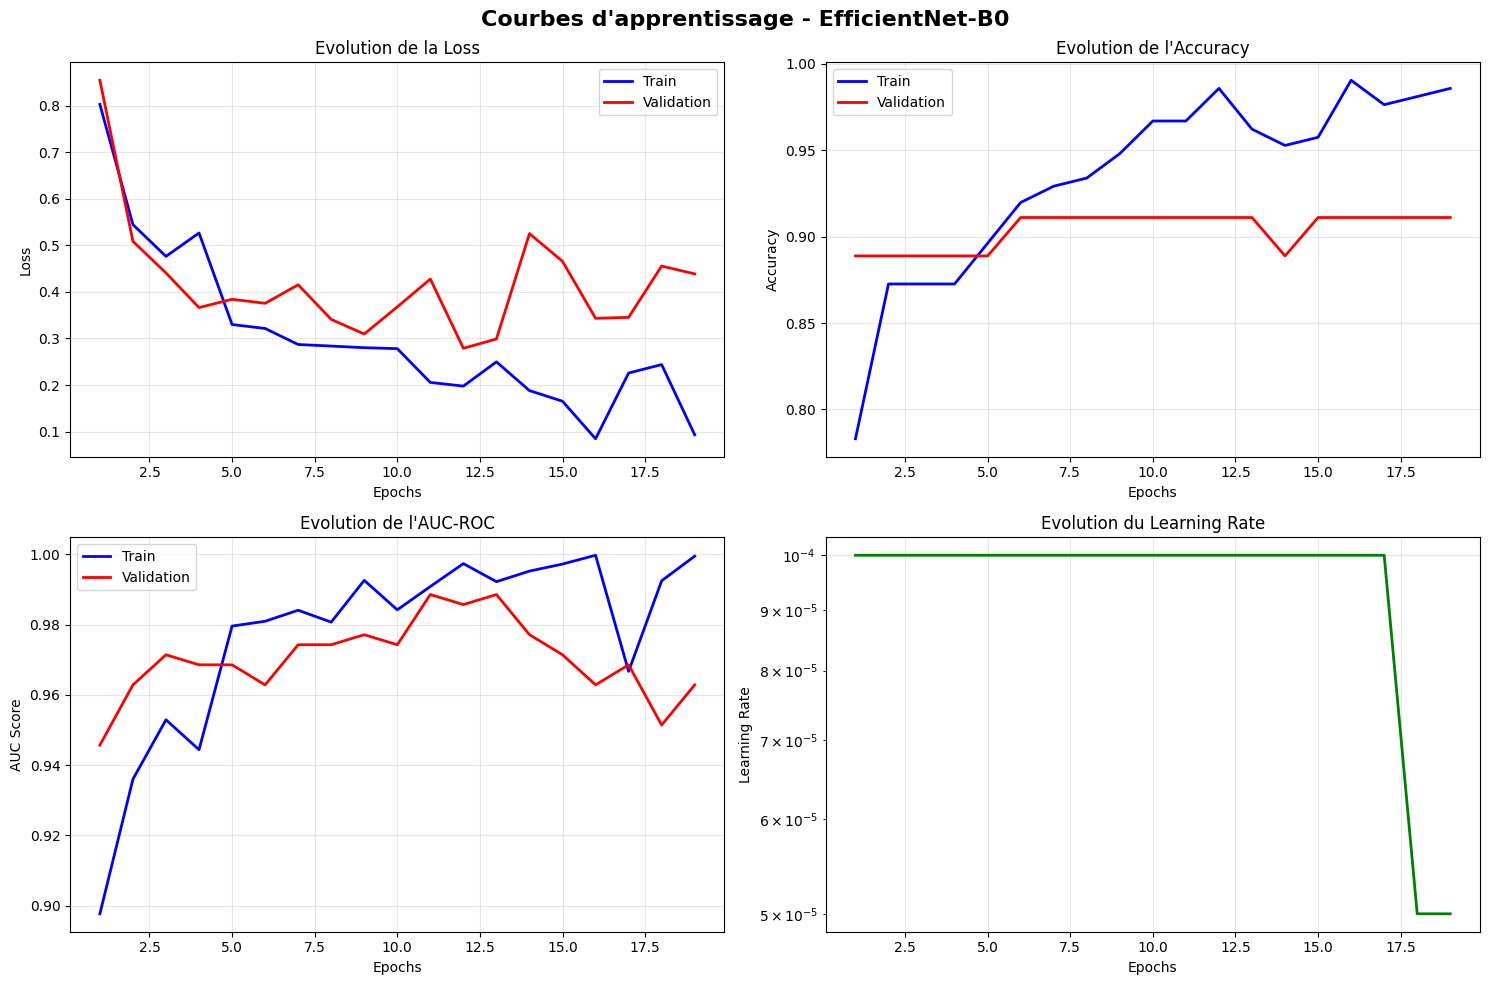


Graphiques sauvegardes dans 'training_curves.png'


In [15]:
# =============================================================================
# 15. VISUALISATION DES COURBES D'APPRENTISSAGE
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Courbes d\'apprentissage - EfficientNet-B0', fontsize=16, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0, 0].set_title('Evolution de la Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[0, 1].plot(epochs_range, history['val_acc'], 'r-', label='Validation', linewidth=2)
axes[0, 1].set_title('Evolution de l\'Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(epochs_range, history['train_auc'], 'b-', label='Train', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_auc'], 'r-', label='Validation', linewidth=2)
axes[1, 0].set_title('Evolution de l\'AUC-ROC')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('AUC Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'g-', linewidth=2)
axes[1, 1].set_title('Evolution du Learning Rate')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraphiques sauvegardes dans 'training_curves.png'")


In [16]:
# =============================================================================
# 16. ANALYSE TRAIN VS VALIDATION
# =============================================================================

final_epoch = len(history['train_loss'])
print(f"\nResume final (Epoch {final_epoch}):")
print("="*70)
print(f"{'Metrique':<20} {'Train':<15} {'Validation':<15} {'Ecart':<10}")
print("-"*70)

for metric in ['loss', 'acc', 'auc']:
    train_val = history[f'train_{metric}'][-1]
    val_val = history[f'val_{metric}'][-1]
    gap = abs(train_val - val_val)
    
    print(f"{metric.upper():<20} {train_val:<15.4f} {val_val:<15.4f} {gap:<10.4f}")

print("="*70)

# Diagnostic overfitting
train_val_gap = abs(history['train_auc'][-1] - history['val_auc'][-1])
if train_val_gap < 0.05:
    print("\nDiagnostic: Pas d'overfitting detecte")
elif train_val_gap < 0.10:
    print("\nDiagnostic: Leger overfitting (acceptable)")
else:
    print("\nDiagnostic: Overfitting detecte")



Resume final (Epoch 19):
Metrique             Train           Validation      Ecart     
----------------------------------------------------------------------
LOSS                 0.0931          0.4388          0.3456    
ACC                  0.9858          0.9111          0.0747    
AUC                  0.9995          0.9629          0.0366    

Diagnostic: Pas d'overfitting detecte


In [17]:
# =============================================================================
# 17. EVALUATION SUR LE TEST SET
# =============================================================================


# Charger le meilleur modele (CORRECTION pour PyTorch 2.6+)
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"\nModele charge (Epoch {checkpoint['epoch']+1}, Val AUC: {checkpoint['val_auc']:.4f})")

# Predictions
model.eval()
test_preds = []
test_probs = []
test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test Set"):
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        
        test_probs.extend(probs)
        test_preds.extend(preds)
        test_labels.extend(labels.numpy())

# Conversion
test_preds = np.array(test_preds).flatten()
test_probs = np.array(test_probs).flatten()
test_labels = np.array(test_labels).flatten()

# Metriques
test_acc = accuracy_score(test_labels, test_preds)
test_auc = roc_auc_score(test_labels, test_probs)

print(f"\nPerformances sur le Test Set:")
print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  AUC-ROC: {test_auc:.4f}")

# Rapport detaille

print("Rapport de Classification:")

print(classification_report(test_labels, test_preds, 
                          target_names=['Normal', 'Glaucome'],
                          digits=4))



Modele charge (Epoch 11, Val AUC: 0.9886)


Test Set: 100%|██████████| 3/3 [00:02<00:00,  1.19it/s]


Performances sur le Test Set:
  Accuracy: 0.9130 (91.30%)
  AUC-ROC: 0.9818
Rapport de Classification:
              precision    recall  f1-score   support

      Normal     0.9429    0.9429    0.9429        35
    Glaucome     0.8182    0.8182    0.8182        11

    accuracy                         0.9130        46
   macro avg     0.8805    0.8805    0.8805        46
weighted avg     0.9130    0.9130    0.9130        46



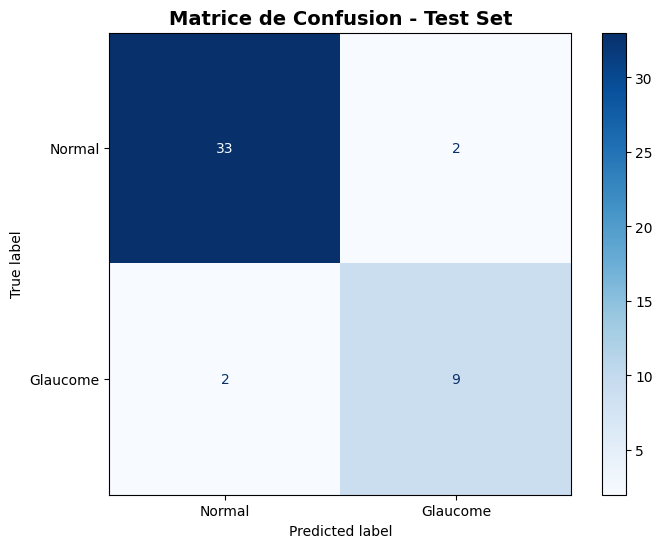


Metriques cliniques:
  Sensibilite (detection glaucome): 0.8182 (81.82%)
  Specificite (detection normal): 0.9429 (94.29%)
  Valeur Predictive Positive: 0.8182
  Valeur Predictive Negative: 0.9429

  Vrais Positifs (TP): 9
  Vrais Negatifs (TN): 33
  Faux Positifs (FP): 2
  Faux Negatifs (FN): 2


In [18]:
# =============================================================================
# 18. MATRICE DE CONFUSION
# =============================================================================

cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Normal', 'Glaucome'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Matrice de Confusion - Test Set', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyse detaillee
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print("\nMetriques cliniques:")
print(f"  Sensibilite (detection glaucome): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  Specificite (detection normal): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Valeur Predictive Positive: {ppv:.4f}")
print(f"  Valeur Predictive Negative: {npv:.4f}")
print(f"\n  Vrais Positifs (TP): {tp}")
print(f"  Vrais Negatifs (TN): {tn}")
print(f"  Faux Positifs (FP): {fp}")
print(f"  Faux Negatifs (FN): {fn}")


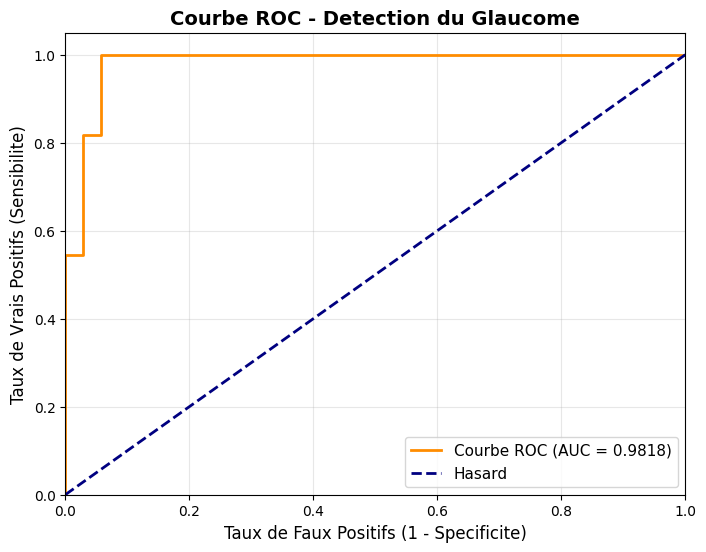


Seuil optimal de decision: 0.3608
  Sensibilite: 1.0000
  Specificite: 0.9429
  Youden's Index: 0.9429


In [19]:
# =============================================================================
# 19. COURBE ROC
# =============================================================================

fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Courbe ROC (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Specificite)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilite)', fontsize=12)
plt.title('Courbe ROC - Detection du Glaucome', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Seuil optimal (Youden's Index)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nSeuil optimal de decision: {optimal_threshold:.4f}")
print(f"  Sensibilite: {tpr[optimal_idx]:.4f}")
print(f"  Specificite: {1-fpr[optimal_idx]:.4f}")
print(f"  Youden's Index: {tpr[optimal_idx] - fpr[optimal_idx]:.4f}")


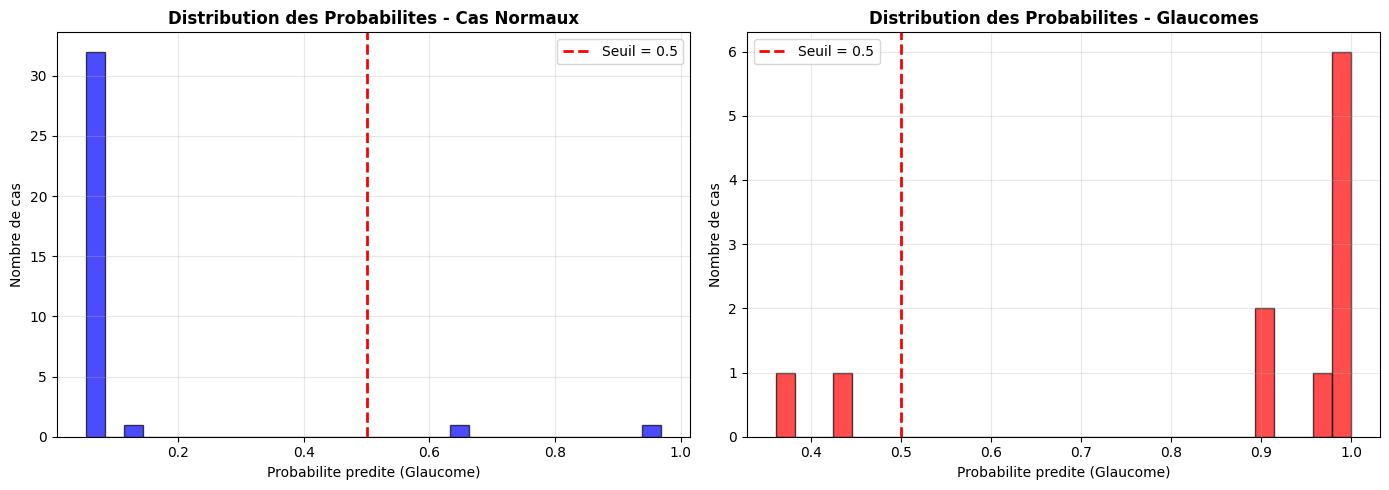


Analyse de confiance:
  Predictions haute confiance (prob > 0.8 ou < 0.2): 43
  Predictions haute confiance correctes: 42
  Taux de precision haute confiance: 0.9767


In [20]:
# =============================================================================
# 20. DISTRIBUTION DES PROBABILITES
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cas normaux
normal_probs = test_probs[test_labels == 0]
axes[0].hist(normal_probs, bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Seuil = 0.5')
axes[0].set_title('Distribution des Probabilites - Cas Normaux', fontweight='bold')
axes[0].set_xlabel('Probabilite predite (Glaucome)')
axes[0].set_ylabel('Nombre de cas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Glaucomes
glaucoma_probs = test_probs[test_labels == 1]
axes[1].hist(glaucoma_probs, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Seuil = 0.5')
axes[1].set_title('Distribution des Probabilites - Glaucomes', fontweight='bold')
axes[1].set_xlabel('Probabilite predite (Glaucome)')
axes[1].set_ylabel('Nombre de cas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyse de confiance
high_conf_correct = np.sum((test_probs > 0.8) & (test_preds == test_labels)) + \
                    np.sum((test_probs < 0.2) & (test_preds == test_labels))
high_conf_total = np.sum((test_probs > 0.8) | (test_probs < 0.2))

print(f"\nAnalyse de confiance:")
print(f"  Predictions haute confiance (prob > 0.8 ou < 0.2): {high_conf_total}")
print(f"  Predictions haute confiance correctes: {high_conf_correct}")
if high_conf_total > 0:
    print(f"  Taux de precision haute confiance: {high_conf_correct/high_conf_total:.4f}")


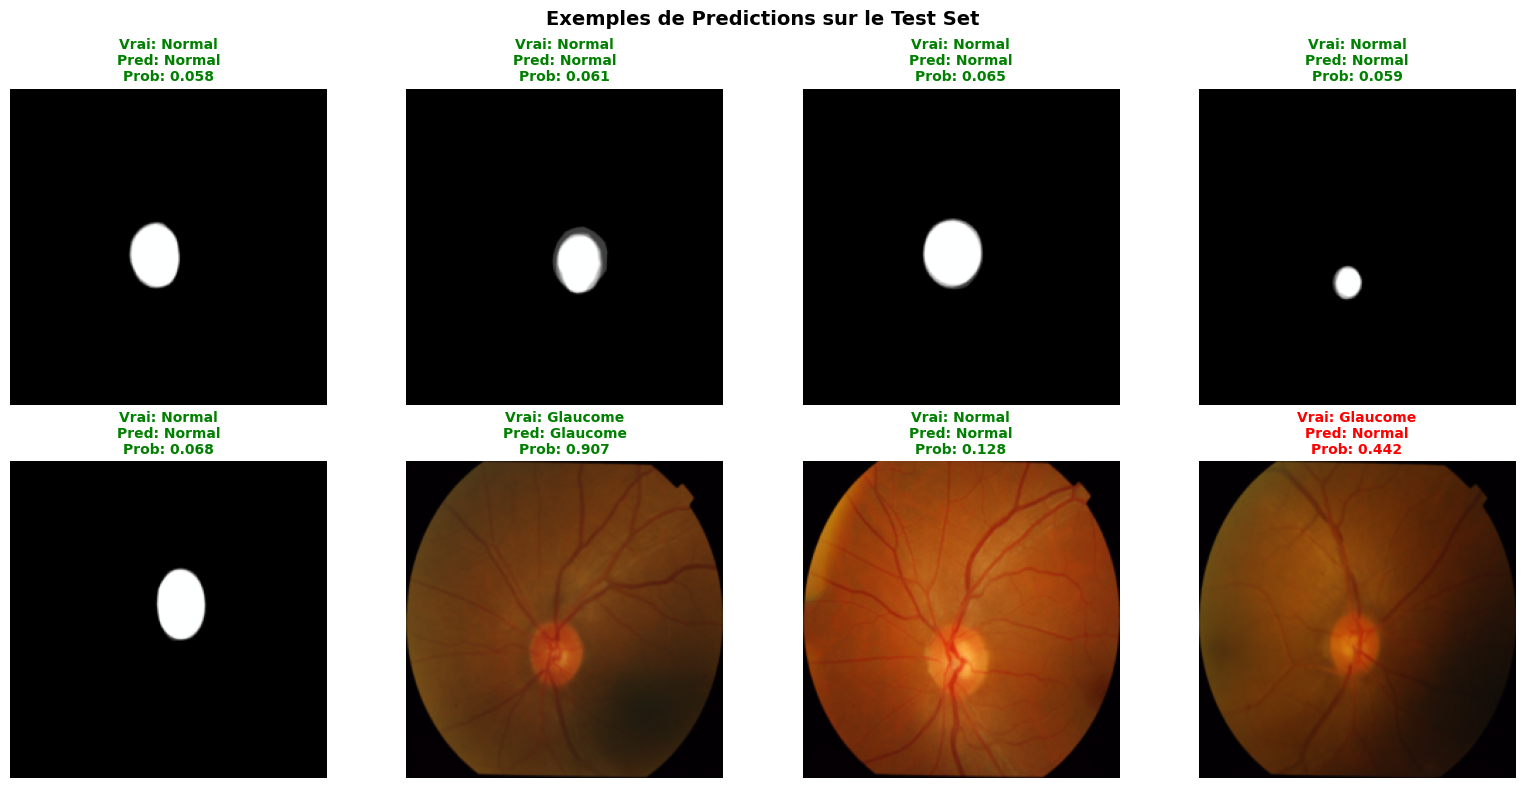

In [21]:
# =============================================================================
# 21. EXEMPLES DE PREDICTIONS
# =============================================================================

np.random.seed(42)
n_samples = 8
indices = np.random.choice(len(test_dataset), n_samples, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

model.eval()
with torch.no_grad():
    for idx, ax in zip(indices, axes):
        image, label = test_dataset[idx]
        image_tensor = image.unsqueeze(0).to(DEVICE)
        
        output = model(image_tensor)
        prob = torch.sigmoid(output).item()
        pred = int(prob > 0.5)
        
        # Denormaliser l'image
        image_np = image.permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image_np = std * image_np + mean
        image_np = np.clip(image_np, 0, 1)
        
        ax.imshow(image_np)
        ax.axis('off')
        
        true_label = 'Glaucome' if label == 1 else 'Normal'
        pred_label = 'Glaucome' if pred == 1 else 'Normal'
        
        color = 'green' if pred == label else 'red'
        title = f'Vrai: {true_label}\nPred: {pred_label}\nProb: {prob:.3f}'
        ax.set_title(title, fontsize=10, color=color, fontweight='bold')

plt.suptitle('Exemples de Predictions sur le Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_examples.png', dpi=300, bbox_inches='tight')
plt.show()


In [22]:
# =============================================================================
# 22. SAUVEGARDE DES RESULTATS
# =============================================================================

results = {
    'model': 'EfficientNet-B0',
    'total_params': int(total_params),
    'trainable_params': int(trainable_params),
    'training': {
        'epochs_trained': len(history['train_loss']),
        'best_val_auc': float(best_val_auc),
        'final_train_loss': float(history['train_loss'][-1]),
        'final_val_loss': float(history['val_loss'][-1]),
        'final_train_acc': float(history['train_acc'][-1]),
        'final_val_acc': float(history['val_acc'][-1]),
        'final_train_auc': float(history['train_auc'][-1]),
        'final_val_auc': float(history['val_auc'][-1])
    },
    'test_performance': {
        'accuracy': float(test_acc),
        'auc_roc': float(test_auc),
        'sensitivity': float(sensitivity),
        'specificity': float(specificity),
        'ppv': float(ppv),
        'npv': float(npv),
        'confusion_matrix': {
            'tp': int(tp),
            'tn': int(tn),
            'fp': int(fp),
            'fn': int(fn)
        }
    },
    'dataset': {
        'train_size': len(train_df),
        'val_size': len(val_df),
        'test_size': len(test_df),
        'class_distribution': {
            'normal': int(num_normal),
            'glaucoma': int(num_glaucoma),
            'ratio': float(pos_weight)
        }
    },
    'hyperparameters': {
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'pos_weight': float(pos_weight)
    }
}

with open('training_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\nResultats sauvegardes dans 'training_results.json'")



Resultats sauvegardes dans 'training_results.json'


In [23]:
# =============================================================================
# 23. RESUME FINAL
# =============================================================================

print(f"""
ARCHITECTURE:
  - Modele: EfficientNet-B0 pre-entraine (ImageNet)
  - Parametres totaux: {total_params:,}
  - Parametres entrainables: {trainable_params:,}
  - Transfer Learning: Gel des 5 premiers blocs

DATASET:
  - Total images: {len(df)}
  - Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)
  - Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)
  - Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)
  - Desequilibre: Ratio {pos_weight:.2f}:1 (Normal:Glaucome)

CONFIGURATION:
  - Loss: BCEWithLogitsLoss (pos_weight={pos_weight:.3f})
  - Optimizer: AdamW (LR={LEARNING_RATE}, WD={WEIGHT_DECAY})
  - Scheduler: ReduceLROnPlateau (patience=5)
  - Early Stopping: patience=7 epochs
  - Data Augmentation: Flip, Rotation, ColorJitter

RESULTATS FINAUX:
  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)
  Test AUC-ROC: {test_auc:.4f}
  
  Sensibilite (detection glaucome): {sensitivity:.4f} ({sensitivity*100:.2f}%)
  Specificite (detection normal): {specificity:.4f} ({specificity*100:.2f}%)
  
  Valeur Predictive Positive: {ppv:.4f}
  Valeur Predictive Negative: {npv:.4f}
  
  Matrice de Confusion:
    Vrais Positifs: {tp:3d}    Faux Positifs: {fp:3d}
    Faux Negatifs:  {fn:3d}    Vrais Negatifs: {tn:3d}

INTERPRETATION CLINIQUE:
  - Le modele detecte correctement {sensitivity*100:.1f}% des cas de glaucome
  - {fn} cas de glaucome non detectes (faux negatifs)
  - {fp} cas de sur-diagnostic (faux positifs)
  - Adapte pour un usage de pre-screening en clinique
  
FICHIERS GENERES:
  - best_efficientnet_glaucoma.pth (poids du modele)
  - training_curves.png
  - confusion_matrix.png
  - roc_curve.png
  - probability_distribution.png
  - prediction_examples.png
  - training_results.json
  - dataset_samples.png
""")




ARCHITECTURE:
  - Modele: EfficientNet-B0 pre-entraine (ImageNet)
  - Parametres totaux: 4,796,541
  - Parametres entrainables: 4,487,881
  - Transfer Learning: Gel des 5 premiers blocs

DATASET:
  - Total images: 303
  - Train: 212 (70.0%)
  - Validation: 45 (14.9%)
  - Test: 46 (15.2%)
  - Desequilibre: Ratio 3.33:1 (Normal:Glaucome)

CONFIGURATION:
  - Loss: BCEWithLogitsLoss (pos_weight=3.329)
  - Optimizer: AdamW (LR=0.0001, WD=0.0005)
  - Scheduler: ReduceLROnPlateau (patience=5)
  - Early Stopping: patience=7 epochs
  - Data Augmentation: Flip, Rotation, ColorJitter

RESULTATS FINAUX:
  Test Accuracy: 0.9130 (91.30%)
  Test AUC-ROC: 0.9818
  
  Sensibilite (detection glaucome): 0.8182 (81.82%)
  Specificite (detection normal): 0.9429 (94.29%)
  
  Valeur Predictive Positive: 0.8182
  Valeur Predictive Negative: 0.9429
  
  Matrice de Confusion:
    Vrais Positifs:   9    Faux Positifs:   2
    Faux Negatifs:    2    Vrais Negatifs:  33

INTERPRETATION CLINIQUE:
  - Le modele de